# **MASK DETECTION IN IMAGES USING RESNET50**#  

![Individual wearing a mask](https://media.giphy.com/media/LM2BXEQUepvjLEgt1N/giphy.gif)

![Masks are important!](https://forthebadge.com/images/badges/check-it-out.svg)


Wearing masks in the midst of the rising corona virus(COVID-19) is made mandatory by a lot of cities. This is a basic resnet implementation that performs binary classification of images and identifies images where the individual is wearing a mask or not.

Also, please take the following measures if you step out:
* Cover mouth and nose with mask and make sure there are no gaps between your face and the mask.
* Avoid touching the mask while using it; if you do, clean your hands with alcohol-based hand rub or soap and water.
* Replace the mask with a new one as soon as it is damp and do not re-use single-use masks.
* To remove the mask: remove it from behind (do not touch the front of mask); discard immediately in a closed bin; clean hands with alcohol-based hand rub or soap and water.

This is a basic implementation using the ResNet50 model. I am a beginner so please feel free to offer corrections and suggestions.

##Architecture of ResNet50

![Arch](https://www.researchgate.net/publication/338603223/figure/fig1/AS:847598516711425@1579094642237/ResNet-50-architecture-26-shown-with-the-residual-units-the-size-of-the-filters-and.png)

In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load in 

#import numpy as np # linear algebra
#import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the "../input/" directory.
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

'''import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))'''

# Any results you write to the current directory are saved as output.

"import os\nfor dirname, _, filenames in os.walk('/kaggle/input'):\n    for filename in filenames:\n        print(os.path.join(dirname, filename))"

In [ ]:
import tensorflow
import keras
import pandas as pd
import numpy as np
from tensorflow.keras.applications import ResNet50
from tensorflow.python.keras.models import Sequential
from tensorflow.python.keras.layers import Dense, Flatten, GlobalAveragePooling2D
from sklearn.datasets import load_files

Using TensorFlow backend.


Importing the training and testing data from respective directories and splitting it into categories for validation using load_files.

In [ ]:
train_dir='/kaggle/input/withwithout-mask/maskdata/maskdata/train/'
test_dir='/kaggle/input/withwithout-mask/maskdata/maskdata/test/'

In [ ]:
def load_dataset(path):
    data = load_files(path) #load all files from the path
    files = np.array(data['filenames']) #get the file  
    targets = np.array(data['target'])#get the the classification labels as integer index
    target_labels = np.array(data['target_names'])#get the the classification labels 
    return files,targets,target_labels
    
x_train, y_train,target_labels = load_dataset(train_dir)
x_test, y_test,_ = load_dataset(test_dir)

print('Training set size : ' , x_train.shape[0])
print('Testing set size : ', x_test.shape[0])

Training set size :  616
Testing set size :  198


In [ ]:
num_classes = 2

Importing resnet weights for importing the pretrained model. Resnet50 is used here because it proves to substantially reduce the number of parameters.

In [ ]:
resnet_weights_path = '../input/resnet50/resnet50_weights_tf_dim_ordering_tf_kernels_notop.h5'

Creating the model and removing its first layer as we wish to train it and not use the pre-trained first layer.

In [ ]:
my_new_model = Sequential()
my_new_model.add(ResNet50(include_top=False, pooling='avg', weights=resnet_weights_path))
my_new_model.add(Dense(num_classes, activation='softmax'))

my_new_model.layers[0].trainable = False

In [ ]:
my_new_model.compile(optimizer='sgd', loss='categorical_crossentropy', metrics=['accuracy'])

Preprocessing the data via ImageDataGenerator.The data here is categorical as it is divided into two categories namely With Mask and Without Mask.

In [ ]:
from keras.applications.resnet50 import ResNet50
from keras.preprocessing import image
from keras.applications.resnet50 import preprocess_input, decode_predictions
from keras_preprocessing.image import ImageDataGenerator
import numpy as np


image_size = 224
data_generator = ImageDataGenerator(preprocessing_function=preprocess_input,horizontal_flip=True,
                                   width_shift_range = 0.2,
                                   height_shift_range = 0.2)


train_generator = data_generator.flow_from_directory(
        train_dir,
        target_size=(image_size, image_size),
        batch_size=50,
        class_mode='categorical')

validation_generator = data_generator.flow_from_directory(test_dir,target_size=(image_size, image_size),
        class_mode='categorical')

history=my_new_model.fit_generator(
        train_generator,
        steps_per_epoch=4,epochs=3,
        validation_data=validation_generator,
        validation_steps=1)

Found 616 images belonging to 2 classes.
Found 198 images belonging to 2 classes.
Train for 4 steps, validate for 1 steps
Epoch 1/3
4/4 [==============================] - 11s 3s/step - loss: 0.7658 - accuracy: 0.5723 - val_loss: 0.5539 - val_accuracy: 0.6875
Epoch 2/3
4/4 [==============================] - 7s 2s/step - loss: 0.4487 - accuracy: 0.7900 - val_loss: 0.3591 - val_accuracy: 0.8750
Epoch 3/3
4/4 [==============================] - 6s 2s/step - loss: 0.2834 - accuracy: 0.9200 - val_loss: 0.2143 - val_accuracy: 0.9688


In [ ]:
my_new_model.save('mask_detector.h5')
print('Model saved to mask_detector.h5')

Plotting accuracies for training and testing.

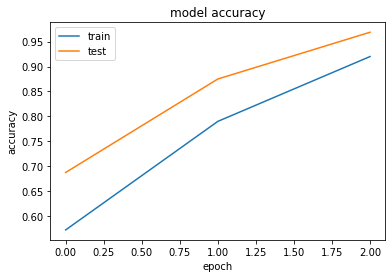

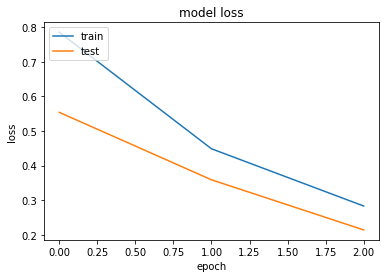

In [ ]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()
# summarize history for loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'test'], loc='upper left')
plt.show()

In [ ]:
import pickle

pickle_out = open("resnet50_history.pickle","wb")
pickle.dump(history.history, pickle_out)
pickle_out.close()

More stats for nerds!

In [ ]:
pickle_in = open("resnet50_history.pickle","rb")
saved_history = pickle.load(pickle_in)
print(saved_history)

{'loss': [0.7852951223591724, 0.4487138167023659, 0.2833753824234009], 'accuracy': [0.57228917, 0.79, 0.92], 'val_loss': [0.5539188385009766, 0.3591010272502899, 0.2143401950597763], 'val_accuracy': [0.6875, 0.875, 0.96875]}


The implementation ends here. Below is just a custom testing model that is created for validation and checking if the model predicts correctly for some new data.

In [ ]:
import random
import cv2

def image_show(image,title):
    print(image)
    img = cv2.imread(image)
    plt.imshow(img)
    plt.title(title)
    plt.show()

Importing small dataset of 8 files for custom testing.

In [ ]:
test_gen1=data_generator.flow_from_directory('/kaggle/input/test-data/test/',target_size=(image_size, image_size),
        class_mode='categorical',shuffle=False)

test_gen1.filenames

Found 8 images belonging to 2 classes.


['0/12without.jpg',
 '0/13without.jpg',
 '0/180.jpg',
 '0/smilewithout.jpg',
 '1/15with.jpg',
 '1/16with.jpg',
 '1/464-with-mask.jpg',
 '1/blackmask.jpg']

In [ ]:
predictions_test=my_new_model.predict_generator(test_gen1)
len(predictions_test)
res_test=[]
for i in predictions_test:
    if i[0]<0.5:
        res_test.append("Not Wearing mask")
    else:
        res_test.append("Wearing mask")

/kaggle/input/test-data/test/1/464-with-mask.jpg


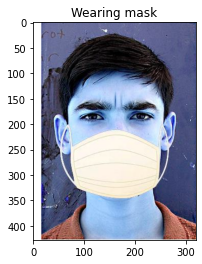

In [ ]:
image_show('/kaggle/input/test-data/test/1/464-with-mask.jpg',res_test[5])

# **Further applications:**

A mask detector like this one can be used in security cameras and only allow entry of those individuals who have a mask on. It will be extremely beneficial and can even lessen the transmission rate.
Another application can be identifying the people wearing masks and not wearing masks in an epicentre of corona virus so as to examine the circumstances and analyse if wearing a mask is really beneficial or not.